In [504]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import matplotlib.pyplot as plt
import seaborn as sns

In [511]:
class StrongBiLSTM(nn.Module):
    # Note: I've reduced the default hidden_size and dropout for this simpler task
    def __init__(self, input_size, hidden_size=64, num_layers=1, dropout=0.3):
        super(StrongBiLSTM, self).__init__()

        self.lstm = nn.LSTM(input_size=input_size,
                            hidden_size=hidden_size,
                            num_layers=num_layers,
                            batch_first=True,
                            dropout=dropout,
                            bidirectional=True)

        self.dropout = nn.Dropout(dropout)
        self.bn = nn.BatchNorm1d(hidden_size * 2)
        self.fc = nn.Linear(hidden_size * 2, 1)

    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        out = lstm_out[:, -1, :]
        # out = self.bn(out)
        out = self.dropout(out)
        out = self.fc(out)
        return out
        
class StockDataset(Dataset):
    def __init__(self, sequences, targets):
        self.sequences = sequences
        self.targets = targets
    
    def __len__(self):
        return len(self.sequences)
    
    def __getitem__(self, idx):
        return (torch.FloatTensor(self.sequences[idx]),
                torch.FloatTensor([self.targets[idx]]))

In [512]:
def prepare_stock_data(df, feature_cols, seq_len=20, train_split=0.7, val_split=0.15):
    stock_data = df.sort_values('Date').reset_index(drop=True)
    
    all_sequences = []
    all_targets = []
    
    if len(stock_data) < seq_len + 1:
        raise ValueError("Not enough data to create sequences.")
        
    X_vals = stock_data[feature_cols].values
    y_vals = stock_data['Target'].values

    for i in range(seq_len, len(X_vals)):
        all_sequences.append(X_vals[i-seq_len:i])
        all_targets.append(y_vals[i])
    
    X_seq = np.array(all_sequences)
    y_seq = np.array(all_targets)
    
    # Split data
    train_idx = int(len(X_seq) * train_split)
    val_idx = int(len(X_seq) * (train_split + val_split))
    
    X_train, y_train = X_seq[:train_idx], y_seq[:train_idx]
    X_val, y_val = X_seq[train_idx:val_idx], y_seq[train_idx:val_idx]
    X_test, y_test = X_seq[val_idx:], y_seq[val_idx:]
    
    return (X_train, y_train), (X_val, y_val), (X_test, y_test)

# --- 1. Load and Filter Data ---
print("Loading and filtering data...")
df_full = pd.read_csv("../data/processed/stock_data_optimized.csv")

# Define the stock and feature you want to train on
STOCK_TO_USE = "AAPL"
FEATURES_TO_USE = [col for col in df_full.columns if col not in ['Date', 'Ticker', 'Target']]

# Filter the DataFrame for the single stock and feature
df_filtered = df_full[df_full['Ticker'] == STOCK_TO_USE].copy()

# Keep only the essential columns for this experiment
essential_cols = FEATURES_TO_USE + ['Date', 'Ticker', 'Target']
df_final = df_filtered[essential_cols]

print(f"Data filtered for Ticker: {STOCK_TO_USE}")
print(f"Using Features: {FEATURES_TO_USE}")
print("Filtered Data Sample:")
print(df_final.head())
# --- 2. Create Sequences from the Filtered Data ---
print("\nCreating sequences from filtered data...")
# Your unscaled, single-feature data splits
(X_train_unscaled, y_train), (X_val_unscaled, y_val), (X_test_unscaled, y_test) = prepare_stock_data(
    df_final,
    feature_cols=FEATURES_TO_USE,
    seq_len=30
)

print(f"Data: {len(X_train_unscaled)} train, {len(X_val_unscaled)} val, {len(X_test_unscaled)} test")
print(f"Features: {X_train_unscaled.shape[2]}")
print(f"Class distribution: {np.bincount(y_train.astype(int))}")


Loading and filtering data...
Data filtered for Ticker: AAPL
Using Features: ['Open', 'High', 'Low', 'Close', 'Volume', 'Log_Return', 'High_Low_Ratio', 'Close_Open_Ratio', 'Gap', 'RSI_14', 'MACD', 'BB_Position', 'ATR_14', 'ADX', 'Volume_Ratio_20', 'Volume_Price_Correlation', 'Close_vs_SMA20', 'Close_vs_SMA50', 'Close_vs_High20d', 'Volatility_20d', 'Return_3d', 'Return_5d', 'ROC_10', 'Momentum_10d', 'Volatility_5d', 'Volatility_Z20', 'High_PrevClose', 'Up_5d', 'OBV', 'Volume_Change_1d', 'Close_Z20', 'Drawdown_10d', 'RSI_14_Lag1', 'MACD_Lag1']
Filtered Data Sample:
      Open    High       Low   Close     Volume  Log_Return  High_Low_Ratio  \
0   528.79  530.89  523.0000  524.69  8471400.0   -0.011295        1.015086   
5   527.70  529.97  525.8500  526.74  7126600.0    0.003899        1.007835   
10  525.90  531.97  525.2001  531.40  7487400.0    0.008808        1.012890   
15  532.26  536.24  529.0000  531.26  8027000.0   -0.000263        1.013686   
20  529.89  532.67  527.3500  528.7

In [513]:
# --- 3. Scale the Data (Using MinMaxScaler for Better Stability) ---
print("\nScaling the data using MinMaxScaler...")

# Initialize the MinMaxScaler to scale data to the [0, 1] range
scaler = MinMaxScaler(feature_range=(0, 1))

# --- FITTING ---
# Reshape the 3D training data to 2D to fit the scaler.
# This learns the min and max values from the training data ONLY.
num_samples, seq_len, num_features = X_train_unscaled.shape
X_train_reshaped = X_train_unscaled.reshape(-1, num_features)
scaler.fit(X_train_reshaped)
print("Scaler has been fitted on the training data.")

# --- TRANSFORMING ---
# Now, transform all datasets using the fitted scaler and reshape them back to 3D.
X_train = scaler.transform(X_train_unscaled.reshape(-1, num_features)).reshape(X_train_unscaled.shape)
X_val = scaler.transform(X_val_unscaled.reshape(-1, num_features)).reshape(X_val_unscaled.shape)
X_test = scaler.transform(X_test_unscaled.reshape(-1, num_features)).reshape(X_test_unscaled.shape)

print("Data successfully scaled to the [0, 1] range.")

# --- VERIFICATION ---
# Verify the range of the new, scaled X_train.
print(f"X_train stats after scaling - min: {X_train.min():.3f}, max: {X_train.max():.3f}")
print("X_train head after scaling:")
print(X_train[:5])


Scaling the data using MinMaxScaler...
Scaler has been fitted on the training data.
Data successfully scaled to the [0, 1] range.
X_train stats after scaling - min: 0.000, max: 1.000
X_train head after scaling:
[[[0.78369352 0.7852683  0.78113514 ... 0.97414008 0.50433285 0.79541392]
  [0.78174674 0.78362709 0.78627027 ... 0.97858747 0.44045504 0.78810592]
  [0.77853188 0.78719495 0.78509928 ... 0.98869713 0.46595619 0.78492409]
  ...
  [0.78417575 0.78569645 0.78374775 ... 0.9847852  0.54036506 0.78547063]
  [0.85409895 0.85503782 0.84911712 ... 1.         0.46161185 0.78494524]
  [0.84752634 0.85858784 0.85493694 ... 1.         0.75698243 0.81668426]]

 [[0.78174674 0.78362709 0.78627027 ... 0.97858747 0.44045504 0.78810592]
  [0.77853188 0.78719495 0.78509928 ... 0.98869713 0.46595619 0.78492409]
  [0.78989105 0.79481233 0.79194595 ... 0.98839341 0.52095734 0.78642827]
  ...
  [0.85409895 0.85503782 0.84911712 ... 1.         0.46161185 0.78494524]
  [0.84752634 0.85858784 0.8549369

In [514]:
# --- 4. Setup DataLoader, Model, and Training Parameters ---
print("\nSetting up model and training components...")
train_dataset = StockDataset(X_train, y_train)
val_dataset = StockDataset(X_val, y_val)
test_dataset = StockDataset(X_test, y_test)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# Initialize the model with the correct input size (which is 1)
model = StrongBiLSTM(input_size=X_train.shape[2]).to(device)

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

print(f"\nModel parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"Device: {device}")


Setting up model and training components...

Model parameters: 51,585
Device: cpu


/opt/homebrew/Caskroom/miniforge/base/envs/stockpredict/lib/python3.9/site-packages/torch/nn/modules/rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.3 and num_layers=1
  warnings.warn(


In [515]:
# --- 5. Training Loop ---
print("\nStarting model training...")
train_losses, val_losses, train_accs, val_accs, learning_rates = [], [], [], [], []

# Hyperparameters for training
num_epochs = 300
best_val_loss = float('inf')
patience_counter = 0
patience = 50

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False) 
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

for epoch in range(num_epochs):
    model.train()
    train_loss, train_correct, train_total = 0, 0, 0
    
    for batch_X, batch_y in train_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        optimizer.zero_grad()
        outputs = model(batch_X).squeeze()
        loss = criterion(outputs, batch_y.squeeze())
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        train_loss += loss.item()
        predictions = (torch.sigmoid(outputs) > 0.5).float()
        train_correct += (predictions == batch_y.squeeze()).sum().item()
        train_total += len(batch_y)
    
    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0
    
    with torch.no_grad():
        for batch_X, batch_y in val_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            outputs = model(batch_X).squeeze()
            loss = criterion(outputs, batch_y.squeeze())
            val_loss += loss.item()
            predictions = (torch.sigmoid(outputs) > 0.5).float()
            val_correct += (predictions == batch_y.squeeze()).sum().item()
            val_total += len(batch_y)
    
    avg_train_loss = train_loss / len(train_loader)
    avg_val_loss = val_loss / len(val_loader)
    train_acc = train_correct / train_total
    val_acc = val_correct / val_total
    current_lr = optimizer.param_groups[0]['lr']
    
    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)
    learning_rates.append(current_lr)
    
    if epoch:
        print(f"Epoch {epoch+1:3d}: Train Loss={avg_train_loss:.4f}, Val Loss={avg_val_loss:.4f}, "
              f"Train Acc={train_acc:.3f}, Val Acc={val_acc:.3f}, LR={current_lr:.6f}")
    
    scheduler.step(avg_val_loss)
    
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        patience_counter = 0
        torch.save(model.state_dict(), 'best_model_single_feature.pth')
    else:
        patience_counter += 1
    
    if patience_counter >= patience:
        print(f"Early stopping at epoch {epoch+1}")
        break

print(f"\nBest validation loss: {best_val_loss:.4f}")


Starting model training...
Epoch   2: Train Loss=0.6767, Val Loss=0.7142, Train Acc=0.589, Val Acc=0.524, LR=0.001000
Epoch   3: Train Loss=0.6750, Val Loss=0.6973, Train Acc=0.589, Val Acc=0.524, LR=0.001000
Epoch   4: Train Loss=0.6739, Val Loss=0.7020, Train Acc=0.595, Val Acc=0.524, LR=0.001000
Epoch   5: Train Loss=0.6738, Val Loss=0.7006, Train Acc=0.595, Val Acc=0.524, LR=0.001000
Epoch   6: Train Loss=0.6711, Val Loss=0.7059, Train Acc=0.597, Val Acc=0.524, LR=0.001000
Epoch   7: Train Loss=0.6710, Val Loss=0.6892, Train Acc=0.593, Val Acc=0.547, LR=0.001000
Epoch   8: Train Loss=0.6681, Val Loss=0.6842, Train Acc=0.599, Val Acc=0.600, LR=0.001000
Epoch   9: Train Loss=0.6730, Val Loss=0.6979, Train Acc=0.596, Val Acc=0.524, LR=0.001000
Epoch  10: Train Loss=0.6730, Val Loss=0.6931, Train Acc=0.598, Val Acc=0.564, LR=0.001000
Epoch  11: Train Loss=0.6712, Val Loss=0.6978, Train Acc=0.589, Val Acc=0.526, LR=0.001000
Epoch  12: Train Loss=0.6668, Val Loss=0.6918, Train Acc=0.601


Running final evaluation on the test set...
Final Test Accuracy: 0.447


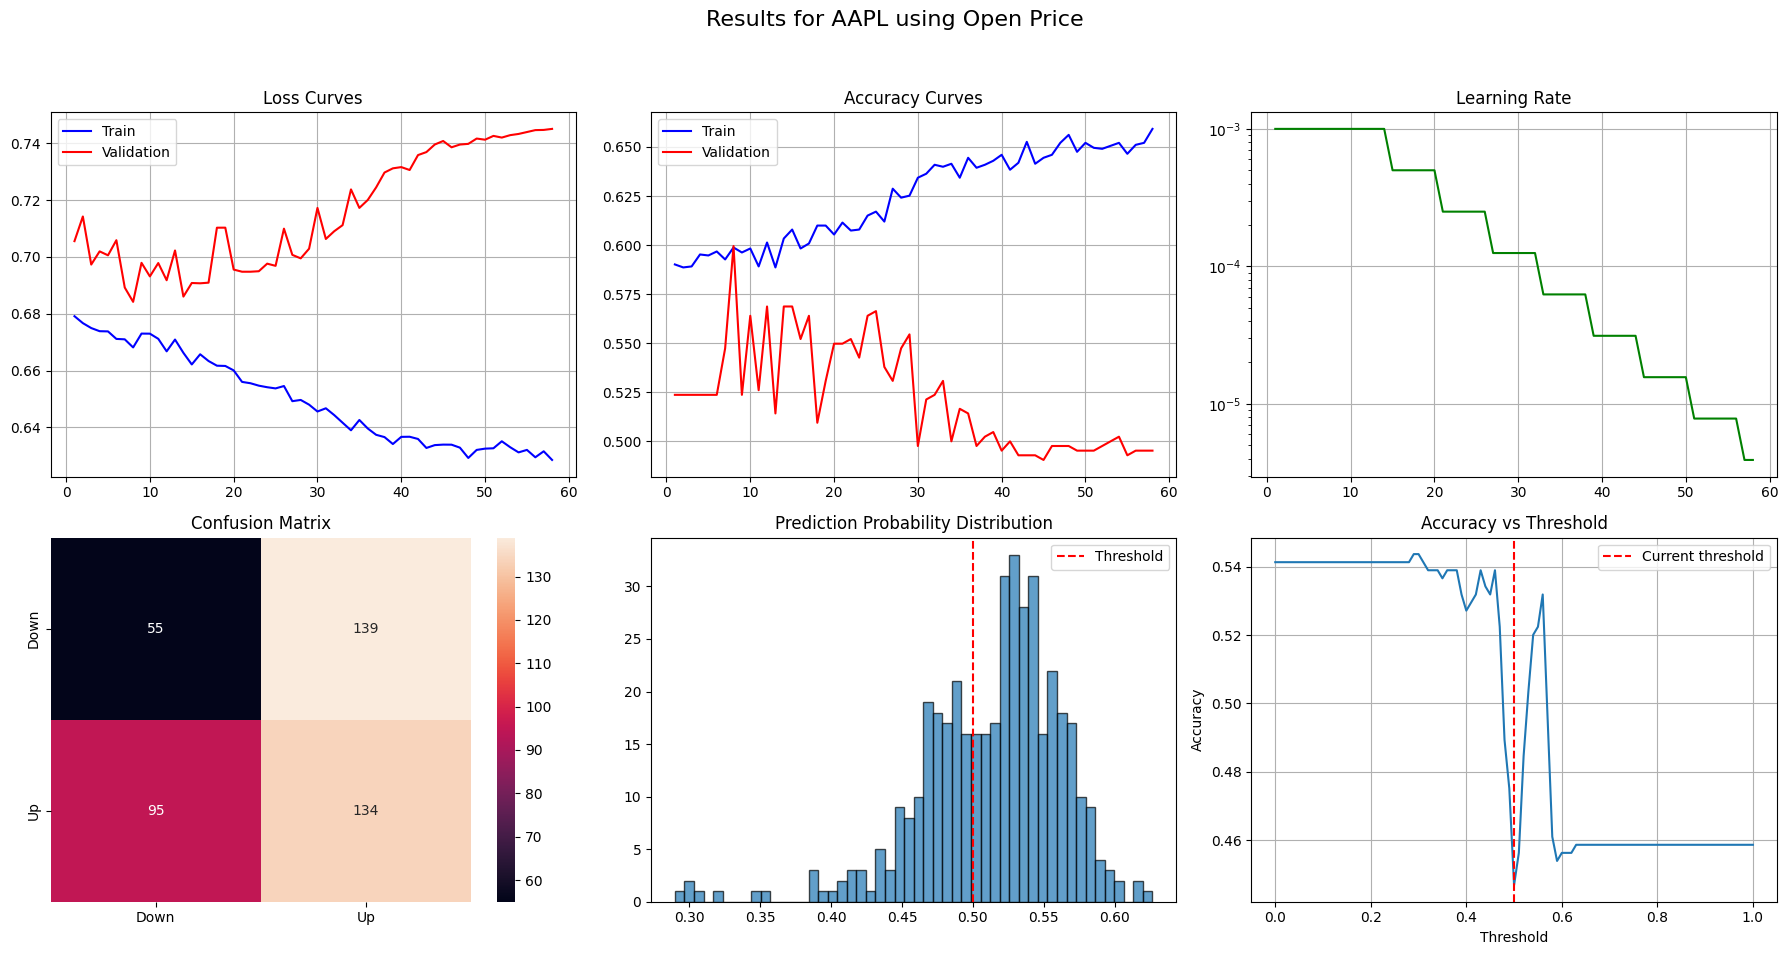


Detailed Classification Report:
              precision    recall  f1-score   support

        Down       0.37      0.28      0.32       194
          Up       0.49      0.59      0.53       229

    accuracy                           0.45       423
   macro avg       0.43      0.43      0.43       423
weighted avg       0.43      0.45      0.44       423



In [516]:
# --- 6. Final Evaluation and Visualization ---
print("\nRunning final evaluation on the test set...")
# Load best model and evaluate
model.load_state_dict(torch.load('best_model_single_feature.pth'))
model.eval()

all_predictions, all_targets, all_probs = [], [], []

with torch.no_grad():
    for batch_X, batch_y in test_loader:
        batch_X = batch_X.to(device)
        # Note: Fixed the model call here, it only takes batch_X
        outputs = model(batch_X).squeeze()
        probs = torch.sigmoid(outputs)
        predictions = (probs > 0.5).float()
        
        all_predictions.extend(predictions.cpu().numpy())
        all_targets.extend(batch_y.squeeze().cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

# Calculate metrics
accuracy = accuracy_score(all_targets, all_predictions)
print(f"Final Test Accuracy: {accuracy:.3f}")

# Create comprehensive visualizations
# ... (Your plotting code from before will work perfectly here) ...
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle(f'Results for {STOCK_TO_USE} using {FEATURES_TO_USE[0]} Price', fontsize=16)

# 1. Training curves
epochs = range(1, len(train_losses) + 1)
axes[0,0].plot(epochs, train_losses, 'b-', label='Train')
axes[0,0].plot(epochs, val_losses, 'r-', label='Validation')
axes[0,0].set_title('Loss Curves')
axes[0,0].legend()
axes[0,0].grid(True)

# ... (The rest of your plotting code is fine) ...
# 2. Accuracy curves
axes[0,1].plot(epochs, train_accs, 'b-', label='Train')
axes[0,1].plot(epochs, val_accs, 'r-', label='Validation')
axes[0,1].set_title('Accuracy Curves')
axes[0,1].legend()
axes[0,1].grid(True)

# 3. Learning rate
axes[0,2].plot(epochs, learning_rates, 'g-')
axes[0,2].set_title('Learning Rate')
axes[0,2].set_yscale('log')
axes[0,2].grid(True)

# 4. Confusion matrix
cm = confusion_matrix(all_targets, all_predictions)
sns.heatmap(cm, annot=True, fmt='d', ax=axes[1,0], 
           xticklabels=['Down', 'Up'], yticklabels=['Down', 'Up'])
axes[1,0].set_title('Confusion Matrix')

# 5. Prediction distribution
axes[1,1].hist(all_probs, bins=50, alpha=0.7, edgecolor='black')
axes[1,1].axvline(x=0.5, color='r', linestyle='--', label='Threshold')
axes[1,1].set_title('Prediction Probability Distribution')
axes[1,1].legend()

# 6. ROC-like accuracy by threshold
thresholds = np.linspace(0, 1, 101)
threshold_accs = [accuracy_score(all_targets, (np.array(all_probs) > thresh).astype(int)) for thresh in thresholds]
axes[1,2].plot(thresholds, threshold_accs)
axes[1,2].axvline(x=0.5, color='r', linestyle='--', label='Current threshold')
axes[1,2].set_title('Accuracy vs Threshold')
axes[1,2].set_xlabel('Threshold')
axes[1,2].set_ylabel('Accuracy')
axes[1,2].legend()
axes[1,2].grid(True)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# Classification report
print("\nDetailed Classification Report:")
print(classification_report(all_targets, all_predictions, target_names=['Down', 'Up']))